# Reference-state comparison

FleXgeo2 can compare every model in an ensemble to a reference state. The distance is Euclidean distance in each residue's `(curvature, torsion)` space, so large values mark residues whose local backbone geometry differs strongly from the reference.

In [1]:
from pathlib import Path
import sys
import tempfile


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file() and (candidate / "pdb2lj5.pdb").is_file():
            return candidate
    raise FileNotFoundError("Could not find the FleXgeo2 repo root containing pyproject.toml and pdb2lj5.pdb")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import matplotlib.image as mpimg
    import matplotlib.pyplot as plt
    import melodia_py  # noqa: F401
    import pandas as pd
    from flexgeo2 import AnalysisConfig, FlexGeo2App, OutputConfig, ReferenceConfig
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        f"Missing dependency: {exc.name}. Install the project in your notebook kernel with `pip install -e .` "
        "or, if you use uv, run `uv sync` and select the project environment as the Jupyter kernel."
    ) from exc

PDB_FILE = REPO_ROOT / "pdb2lj5.pdb"
tmpdir = tempfile.TemporaryDirectory(prefix="flexgeo2_reference_")
OUTPUT_DIR = Path(tmpdir.name)
print(f"Temporary output directory: {OUTPUT_DIR}")

Temporary output directory: /var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2_reference_rz5t8u2w


## Compare the ensemble to model 1

`ReferenceConfig(model_id="1")` selects model 1 from the input PDB as the reference state.

In [2]:
result = FlexGeo2App().run(
    AnalysisConfig(
        pdb_file=PDB_FILE,
        chains=["A"],
        n_jobs=1,
        reference=ReferenceConfig(model_id="1"),
        output=OutputConfig(output_dir=OUTPUT_DIR, verbose=True, write_files=True),
    )
)

distance_result = result.distance_result
assert distance_result is not None
distance_result.reference_label

'input model 1'

## Inspect distance tables

`long_df` has one row per model and residue. `summary_df` collapses the distances across the ensemble by residue.

In [3]:
distance_result.long_df.head()

,chain,model,order,name,residue_label,curvature,torsion,reference_curvature,reference_torsion,distance_to_reference,reference_label
0,A,0,1,MET,MET1,0.520270,0.020683,0.663950,-0.015549,0.148178,input model 1
1,A,0,2,GLN,GLN2,0.520270,0.020683,0.663950,-0.015549,0.148178,input model 1
2,A,0,3,ILE,ILE3,0.689421,-0.042487,0.740639,-0.082568,0.065037,input model 1
3,A,0,4,PHE,PHE4,0.634875,-0.100278,0.783802,-0.121884,0.150485,input model 1
4,A,0,5,VAL,VAL5,0.824192,-0.094061,0.891091,-0.109700,0.068703,input model 1


In [4]:
distance_result.summary_df.head()

,chain,order,name,residue_label,distance_mean,distance_std,distance_min,distance_max,models
0,A,1,MET,MET1,0.150726,0.064124,0.0,0.338234,301
1,A,2,GLN,GLN2,0.150726,0.064124,0.0,0.338234,301
2,A,3,ILE,ILE3,0.158926,0.061891,0.0,0.321696,301
3,A,4,PHE,PHE4,0.171127,0.069483,0.0,0.370383,301
4,A,5,VAL,VAL5,0.093929,0.062754,0.0,0.289868,301


## Top residues by distance to reference

Mean distance highlights consistently different residues. Max distance highlights residues with at least one strongly divergent model.

In [5]:
distance_result.summary_df.sort_values("distance_mean", ascending=False).head(10)[
    ["chain", "residue_label", "distance_mean", "distance_std", "distance_max", "models"]
]

,chain,residue_label,distance_mean,distance_std,distance_max,models
61,A,GLN62,0.531001,0.346635,1.431100,301
74,A,GLY75,0.465939,0.528741,4.106536,301
75,A,GLY76,0.465939,0.528741,4.106536,301
71,A,ARG72,0.462493,0.300474,2.868758,301
70,A,LEU71,0.446970,0.275792,1.390220,301
67,A,HIS68,0.381722,0.208951,2.019937,301
15,A,GLU16,0.341266,0.123908,0.656889,301
72,A,LEU73,0.321457,0.194409,1.101958,301
73,A,ARG74,0.253707,0.189098,1.372808,301
9,A,GLY10,0.237940,0.172612,0.968849,301


In [6]:
distance_result.summary_df.sort_values("distance_max", ascending=False).head(10)[
    ["chain", "residue_label", "distance_mean", "distance_std", "distance_max", "models"]
]

,chain,residue_label,distance_mean,distance_std,distance_max,models
75,A,GLY76,0.465939,0.528741,4.106536,301
74,A,GLY75,0.465939,0.528741,4.106536,301
71,A,ARG72,0.462493,0.300474,2.868758,301
68,A,LEU69,0.183189,0.162825,2.221743,301
67,A,HIS68,0.381722,0.208951,2.019937,301
65,A,THR66,0.177004,0.198317,1.664874,301
61,A,GLN62,0.531001,0.346635,1.431100,301
70,A,LEU71,0.446970,0.275792,1.390220,301
73,A,ARG74,0.253707,0.189098,1.372808,301
72,A,LEU73,0.321457,0.194409,1.101958,301


## Distance heatmap

The heatmap puts models on one axis and residues on the other. Brighter regions are farther from the reference model in curvature/torsion space.

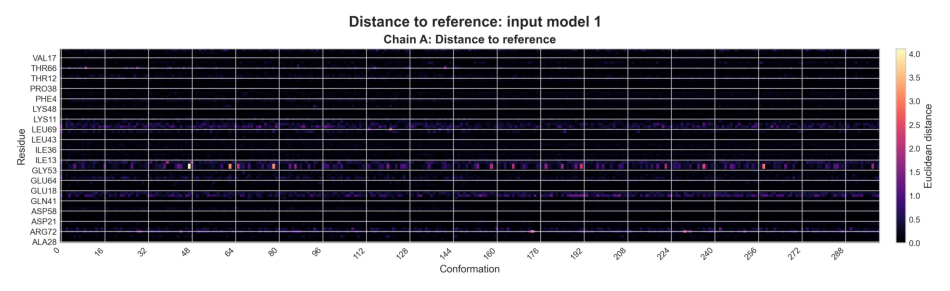

In [15]:
assert result.outputs.distance_heatmap is not None and result.outputs.distance_heatmap.is_file()
img = mpimg.imread(result.outputs.distance_heatmap)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

## External references

To compare against a different PDB file, use `ReferenceConfig(pdb_file="path/to/reference.pdb", pdb_model_id="1")`. If `pdb_model_id` is omitted, FleXgeo2 uses the first model in the reference file.